# Voorspellen van brandstofverbruik (MPG) met een Decision Tree Regressor

In College 3 hebben we een OLS regressie gebruikt om een voorspelling te doen over de `MPG` (miles per gallon) van auto's.
In dit notebook gebruiken we een **Decision Tree Regressor** om de MPG van auto's te voorspellen op basis van hun kenmerken.

We gaan de volgende stappen doorlopen:

1. Data inladen en verkennen  
2. Features (`X`) en target (`y`) definiëren  
3. Train/test-split maken  
4. Een `DecisionTreeRegressor` trainen  
5. Het model evalueren op train- en testset  
6. (Optioneel) Kijken naar feature importances


In [2]:
# ===== 1. Imports en data inladen =====
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Dataset laden (pad aanpassen indien nodig)
cars_df = pd.read_excel("./data/cars.xls")

# Eerste paar rijen tonen ter controle
cars_df.head()


,Model,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Year,Origin
0,chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,US
1,buick skylark 320,15.0,8,350.0,165,3693,11.5,70,US
2,plymouth satellite,18.0,8,318.0,150,3436,11.0,70,US
3,amc rebel sst,16.0,8,304.0,150,3433,12.0,70,US
4,ford torino,17.0,8,302.0,140,3449,10.5,70,US


## 2. Features (X) en target (y) definiëren

We kiezen `MPG` als doelvariabele (`y`) en een aantal kolommen als inputfeatures (`X`).

> Let op: dit is vergelijkbaar met je OLS-voorbeeld.  
> Als je later wilt experimenteren, kun je hier gemakkelijk kolommen weghalen/toevoegen.


In [3]:
# Doelvariabele (y) en kenmerken (X) instellen
y = cars_df['MPG']

# Zelfde features als bij OLS
X = cars_df[['Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration', 'Year']]
# Eventueel simpel model:
# X = cars_df[['Weight', 'Year']]

# One-hot encoding als er categorische variabelen zouden zijn
# (bijvoorbeeld 'Origin', als je die toevoegt aan X)
X = pd.get_dummies(X, drop_first=True)

print(X.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Cylinders     392 non-null    int64  
 1   Displacement  392 non-null    float64
 2   Horsepower    392 non-null    int64  
 3   Weight        392 non-null    int64  
 4   Acceleration  392 non-null    float64
 5   Year          392 non-null    int64  
dtypes: float64(2), int64(4)
memory usage: 18.5 KB
None


## 3. Train- en test-split

We splitsen de data in een trainingsset en een testset.

- 70% voor training  
- 30% voor testen  
- `random_state` zetten we vast voor reproduceerbaarheid.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=4
)

# Index resetten (niet per se nodig voor sklearn, maar wel netjes)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

X_train.shape, X_test.shape


((274, 6), (118, 6))

## 4. Decision Tree Regressor trainen

In tegenstelling tot OLS (lineaire regressie) is een decision tree:

- **Niet-lineair**
- Kan complexe relaties en interacties tussen features modelleren
- Is gevoelig voor overfitting als de boom te diep wordt

We starten met een eenvoudige boom met een beperkte `max_depth` om overfitting te beperken.


In [5]:
# ===== 4. Model definiëren en trainen =====
tree_reg = DecisionTreeRegressor(
    random_state=4,
    max_depth=4,          # probeer later andere waarden (None, 3, 5, 10, ...)
    min_samples_leaf=5    # voorkomt dat er blaadjes met heel weinig samples ontstaan
)

tree_reg.fit(X_train, y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,4
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


## 5. Model evalueren

We evalueren het model met de volgende metrics:

- **R² (coefficient of determination)** – hoeveel variantie in `y` wordt verklaard?
- **MSE (Mean Squared Error)** – gemiddelde kwadratische fout
- **MAE (Mean Absolute Error)** – gemiddelde absolute fout

We doen dit zowel op de **trainset** als de **testset** om te zien of het model overfit.


In [6]:
# ===== 5. Evaluatie =====

# Voorspellingen
y_train_pred = tree_reg.predict(X_train)
y_test_pred = tree_reg.predict(X_test)

def print_regression_metrics(y_true, y_pred, label=""):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {label} ---")
    print(f"R²   : {r2:.3f}")
    print(f"MSE  : {mse:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"MAE  : {mae:.3f}")
    print()

print_regression_metrics(y_train, y_train_pred, label="Trainset")
print_regression_metrics(y_test, y_test_pred, label="Testset")


--- Trainset ---
R²   : 0.898
MSE  : 6.030
RMSE : 2.456
MAE  : 1.789

--- Testset ---
R²   : 0.791
MSE  : 12.932
RMSE : 3.596
MAE  : 2.427



### Interpretatie

- Als **R² op de trainset heel hoog is** (bijna 1.0) maar op de testset veel lager, is er waarschijnlijk sprake van **overfitting**.
- Door te spelen met `max_depth`, `min_samples_split` en `min_samples_leaf` kun je de boom beter generaliseren naar de testset.


## 6. (Optioneel) Feature importances

Decision trees geven een indicatie van welke features belangrijk zijn voor de voorspelling.  
We kunnen deze **feature importances** bekijken om inzicht te krijgen in de bijdrage van elke variabele.


In [7]:
import matplotlib.pyplot as plt

feature_importances = pd.Series(
    tree_reg.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importances


Cylinders       0.639160
Weight          0.161059
Year            0.141201
Horsepower      0.058580
Displacement    0.000000
Acceleration    0.000000
dtype: float64

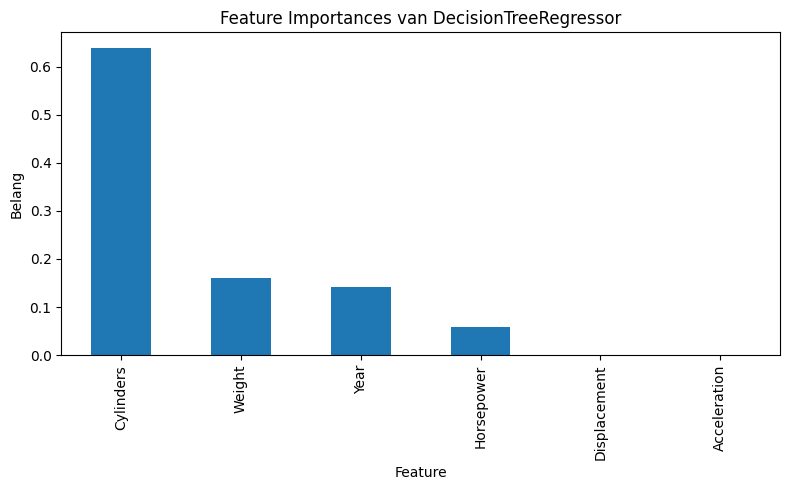

In [8]:
# Mooie plot van feature importances
plt.figure(figsize=(8, 5))
feature_importances.plot(kind='bar')
plt.title("Feature Importances van DecisionTreeRegressor")
plt.ylabel("Belang")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()


## 7. Verder experimenteren

Enkele ideeën om verder te spelen:

- Verander de set features (bijv. minder of juist meer kolommen).
- Pas `max_depth`, `min_samples_leaf` en `min_samples_split` aan.
- Vergelijk prestaties van:
  - OLS-regressie (lineair)
  - DecisionTreeRegressor
  - RandomForestRegressor (ensemble van meerdere bomen)

Zo krijg je gevoel voor de trade-offs tussen eenvoudige lineaire modellen en flexibele non-lineaire modellen.


In [9]:
import pandas as pd
import numpy as np

# Tree-object uit het getrainde model
tree_ = tree_reg.tree_

# Feature-namen uit je design matrix (na get_dummies)
feature_names = X.columns.tolist()

nodes = []
for node_id in range(tree_.node_count):
    feature_idx = tree_.feature[node_id]
    
    # In sklearn: feature_idx < 0 betekent LEAF (meestal -2 = TREE_UNDEFINED)
    if feature_idx < 0:
        feature_name = "LEAF"
        threshold = np.nan
    else:
        feature_name = feature_names[feature_idx]
        threshold = tree_.threshold[node_id]
    
    nodes.append({
        "node_id": node_id,
        "feature_used": feature_name,
        "threshold": threshold,
        "samples": tree_.n_node_samples[node_id],
        "impurity": tree_.impurity[node_id],   # bij regressie: MSE in die knoop
        "is_leaf": feature_idx < 0
    })

overview = pd.DataFrame(nodes)
print(overview)


    node_id feature_used  threshold  samples   impurity  is_leaf
0         0    Cylinders        5.5      274  59.383367    False
1         1       Weight     2217.5      154  35.888121    False
2         2         Year       77.5       74  26.297022    False
3         3       Weight     2091.5       36  12.707562    False
4         4         LEAF        NaN       23   7.325142     True
5         5         LEAF        NaN       13   9.985207     True
6         6   Horsepower       67.5       38  14.017292    False
7         7         LEAF        NaN       18  14.026944     True
8         8         LEAF        NaN       20   8.682100     True
9         9         Year       78.5       80  21.522736    False
10       10       Weight     2775.0       50   5.509764    False
11       11         LEAF        NaN       41   4.167805     True
12       12         LEAF        NaN        9   2.328889     True
13       13       Weight     2580.0       30  18.804489    False
14       14         LEAF 

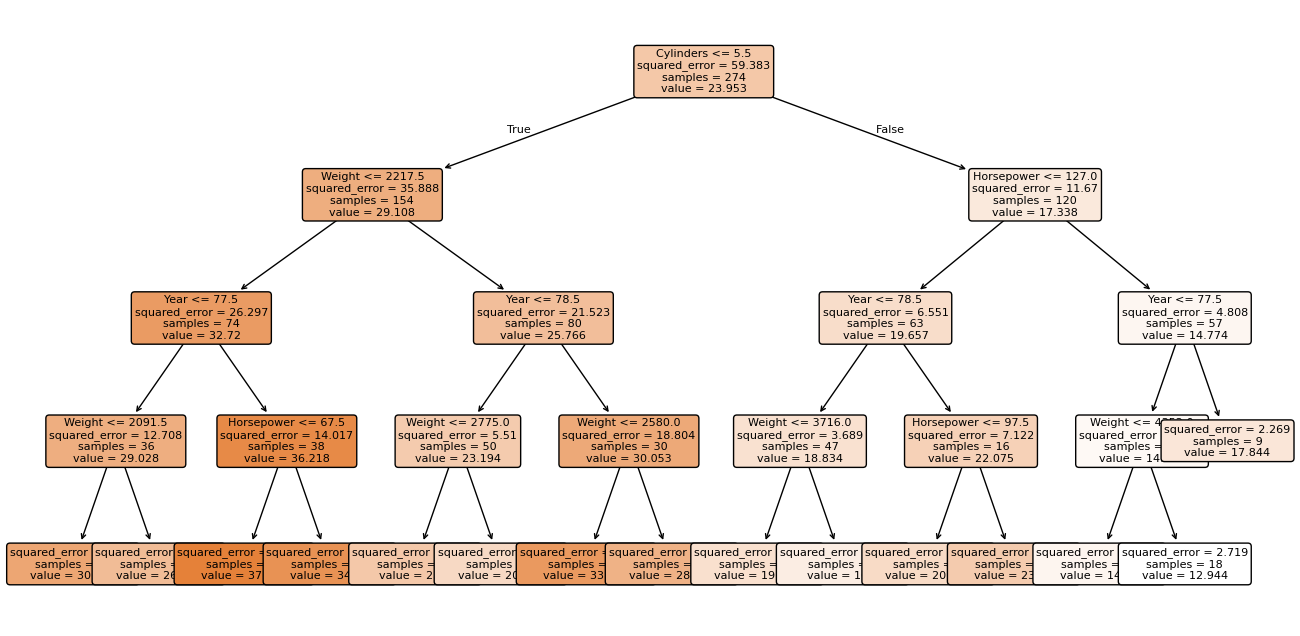

In [10]:
from sklearn.tree import plot_tree
plt.figure(figsize=(16, 8))
plot_tree(
    tree_reg,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()
